In [36]:
import numpy as np


''''Creates the seed for testing'''
rs1 = np.random.RandomState(1)
rs2 = np.random.RandomState(1)

print(rs1.randint(0, 10, size=3))
print(rs2.randint(0, 10, size=3))
print(np.random.randint(0, 10, size=3))

[5 8 9]
[5 8 9]
[8 2 0]


In [38]:
'''Tests the shapes for samples and feature number'''
X = np.ones(12).reshape(2, 6)
print(X)
print(X.shape[0])
print(X.shape[1])

[[1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1.]]
2
6


In [40]:
w = np.array([1, 2, 3, 4, 5])
w + 0.06

array([1.06, 2.06, 3.06, 4.06, 5.06])

In [42]:
errors = []
update = 0.0

x = update != 0.0
print(x)
l = int(x)
l

False


0

In [44]:
'''Creates an 6-dimensional array'''
w = np.random.RandomState(1).normal(loc=0.0, scale=0.01, size=X.shape[1])
w

array([ 0.01624345, -0.00611756, -0.00528172, -0.01072969,  0.00865408,
       -0.02301539])

In [118]:
import numpy as np
class Perceptron_v:
    """Perceptron classifier.
    
    Parameters
    ------------
    eta : float
      Learning rate (between 0.0 and 1.0)
    n_iter : int
      Passes over the training dataset.
    random_state : int
      Random number generator seed for random weight 
      initialization.
    
    Attributes
    -----------
    w_ : 1d-array
      Weights after fitting.
    b_ : Scalar
      Bias unit after fitting.
    errors_ : list
      Number of misclassifications (updates) in each epoch.
    
    """
    #Class definition
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state


    #Method of the peceptron class. 
    def fit(self, X, y):
        """Fit training data.
        
        Parameters
        ----------
        X : {array-like}, shape = [n_examples, n_features] #Number of rows and columns?
          Training vectors, where n_examples is the number of 
          examples and n_features is the number of features.

    
        y : array-like, shape = [n_examples]
          Target values.
        
        Returns
        -------
        self : object
        
        """
        #We fix the random state. In this case is 1
        rgen = np.random.RandomState(self.random_state) 

        #Generates random numbers close to zero and that are equal to the number of features
        self.w_ = rgen.normal(loc=0.0, scale=0.01,
                              size=1+X.shape[1])  

        #b is defined as a float64
        #self.b_ = np.float_(0.)

        #c is defined as an empty list
        self.errors_ = []

        # _ is a dummy variable we don't need
        for _ in range(self.n_iter):
            errors = 0
            for xi, target in zip(X, y):
                print(f'\nBefore updates: Value of xi = {xi} and y = {target}. The perceptrons values are {self.w_[1:]} and {self.w_[0]}') 
                print(f'The value for net input is {self.net_input(xi)} and for predict {self.predict(xi)}')              
                
                update = self.eta * (target - self.predict(xi))
                self.w_[1:] += update * xi
                self.w_[0] += update
                errors += int(update != 0.0)
                
                print(f'\nAfter updates: Value of xi = {xi} and y = {target}. The perceptrons values are {self.w_[1:]} and {self.w_[0]}') 
                #print(f'The value for net input is {self.net_input(xi)} and for predict {self.predict(xi)}')
                print(f'The parameters are {self.eta}. The values for the updates are {self.w_[1:]} and {self.w_[0]} and the number of errors are {errors}')
            self.errors_.append(errors)
            print(f'The parameters are {self.eta}. The values for the updates are {self.w_[1:]} and {self.w_[0]} and the number of errors are {self.errors_} and the function error is {self.errors_}')
        return self
    
    def net_input(self, X):
        """Calculate net input"""
        return np.dot(X, self.w_[1:]) + self.w_[0]
    
    def predict(self, X):
        """Return class label after unit step"""
        return np.where(self.net_input(X) >= 0.0, 1, -1)


In [120]:
import pandas as pd
df = pd.read_csv('https://archive.ics.uci.edu/ml/'
                  'machine-learning-databases/iris/iris.data',
                  header=None)

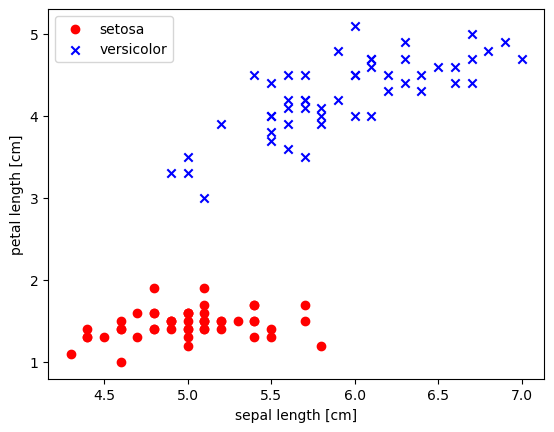


Before updates: Value of xi = [5.1 1.4] and y = -1. The perceptrons values are [-0.00611756 -0.00528172] and 0.01624345363663242
The value for net input is -0.022350527991209804 and for predict -1

After updates: Value of xi = [5.1 1.4] and y = -1. The perceptrons values are [-0.00611756 -0.00528172] and 0.01624345363663242
The parameters are 0.1. The values for the updates are [-0.00611756 -0.00528172] and 0.01624345363663242 and the number of errors are 0

Before updates: Value of xi = [4.9 1.4] and y = -1. The perceptrons values are [-0.00611756 -0.00528172] and 0.01624345363663242
The value for net input is -0.021127015163909656 and for predict -1

After updates: Value of xi = [4.9 1.4] and y = -1. The perceptrons values are [-0.00611756 -0.00528172] and 0.01624345363663242
The parameters are 0.1. The values for the updates are [-0.00611756 -0.00528172] and 0.01624345363663242 and the number of errors are 0

Before updates: Value of xi = [4.7 1.3] and y = -1. The perceptrons value

In [122]:
'''Visual representation'''
import matplotlib.pyplot as plt
import numpy as np

# Selects setosa and versicolor
y = df.iloc[0:100, 4].values

# Sets the features as -1 and 1. 1 to versicolor and -1 otherwise (setosa)
y = np.where(y == 'Iris-setosa', -1, 1)

# extract sepal length and petal length
X = df.iloc[0:100, [0, 2]].values

# Plotting the data
plt.scatter(X[:50, 0], X[:50, 1],
            color='red', marker='o', label='setosa')
plt.scatter(X[50:100, 0], X[50:100, 1],
            color='blue', marker='x', label='versicolor') 

plt.xlabel('sepal length [cm]')
plt.ylabel('petal length [cm]')
plt.legend(loc='upper left')
plt.show()

ppn = Perceptron_v(eta=0.1, n_iter=10)
ppn.fit(X, y)

In [89]:
np.dot([5.1, 1.4], [-0.51611756, -0.14528172]) + (-0.08375654636336759)

-2.9193505103633672

In [109]:
0.01624345363663242 - 0.1 

-0.08375654636336759


Before updates: Value of xi = [5.1 1.4] and y = -1. The perceptrons values are [-0.00611756 -0.00528172] and 0.01624345363663242
The value for net input is -0.022350527991209804 and for predict -1

After updates: Value of xi = [5.1 1.4] and y = -1. The perceptrons values are [-0.00611756 -0.00528172] and 0.01624345363663242
The parameters are 0.1. The values for the updates are [-0.00611756 -0.00528172] and 0.01624345363663242 and the number of errors are 0

Before updates: Value of xi = [4.9 1.4] and y = -1. The perceptrons values are [-0.00611756 -0.00528172] and 0.01624345363663242
The value for net input is -0.021127015163909656 and for predict -1

After updates: Value of xi = [4.9 1.4] and y = -1. The perceptrons values are [-0.00611756 -0.00528172] and 0.01624345363663242
The parameters are 0.1. The values for the updates are [-0.00611756 -0.00528172] and 0.01624345363663242 and the number of errors are 0

Before updates: Value of xi = [4.7 1.3] and y = -1. The perceptrons value

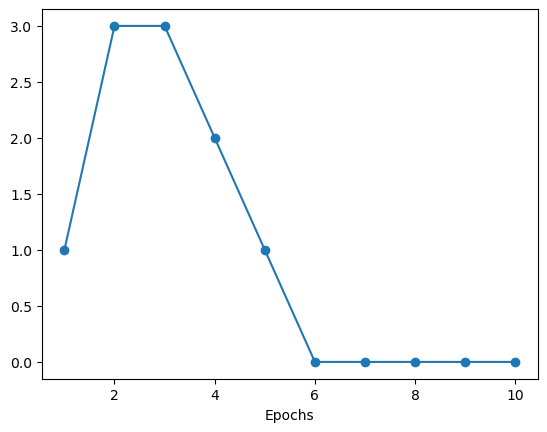

In [124]:
ppn = Perceptron_v(eta=0.1, n_iter=10)
ppn.fit(X, y)
plt.plot(range(1, len(ppn.errors_) + 1), 
         ppn.errors_, marker='o')
plt.xlabel('Epochs')
plt.show()  #The results seem to be odd # 
            #Compare multiple results

In [111]:
import numpy as np

class Perceptron(object):
    """Perceptron classifier.

    Parameters
    ------------
    eta : float
      Learning rate (between 0.0 and 1.0)
    n_iter : int
      Passes over the training dataset.
    random_state : int
      Random number generator seed for random weight
      initialization.

    Attributes
    -----------
    w_ : 1d-array
      Weights after fitting.
    errors_ : list
      Number of misclassifications (updates) in each epoch.

    """
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        """Fit training data.

        Parameters
        ----------
        X : {array-like}, shape = [n_samples, n_features]
          Training vectors, where n_samples is the number of 
          samples and
          n_features is the number of features.
        y : array-like, shape = [n_samples]
          Target values.

        Returns
        -------
        self : object

        """
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, 
                              size=1 + X.shape[1])
        self.errors_ = []

        for _ in range(self.n_iter):
            errors = 0
            for xi, target in zip(X, y):
                print(f'\nBefore updates: Value of xi = {xi} and y = {target}. The perceptrons values are {self.w_[1:]} and {self.w_[0]}') 
                print(f'The value for net input is {self.net_input(xi)} and for predict {self.predict(xi)}')    
                
                update = self.eta * (target - self.predict(xi))
                self.w_[1:] += update * xi
                self.w_[0] += update
                errors += int(update != 0.0)

                print(f'\nAfter updates: Value of xi = {xi} and y = {target}. The perceptrons values are {self.w_[1:]} and {self.w_[0]}') 
                #print(f'The value for net input is {self.net_input(xi)} and for predict {self.predict(xi)}')
                print(f'The parameters are {self.eta}. The values for the updates are {self.w_[1:]} and {self.w_[0]} and the number of errors are {errors}')
            self.errors_.append(errors)
            print(f'The parameters are {self.eta}. The values for the updates are {self.w_[1:]} and {self.w_[0]} and the number of errors are {self.errors_} and the function error is {self.errors_}')
        return self

    def net_input(self, X):
        """Calculate net input"""
        return np.dot(X, self.w_[1:]) + self.w_[0]

    def predict(self, X):
        """Return class label after unit step"""
        return np.where(self.net_input(X) >= 0.0, 1, -1)

### The weights are not initialized to since the learning rate $\eta$ (eta) only has an effect on the classification outcome if the weights are initialized to non-zero values. It is important to keep in mind that the condition is based on $\omega^{T}x$. If $\omega^{T}x > 0$ then the output is $1$ and -1 otherwise

In [104]:
'''Two vectors that are linearly dependent'''
v1 = np.array([1, 2, 3])
v2 = 0.5 * v1
np.arccos(v1.dot(v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)))

0.0

In [106]:
import pandas as pd
df = pd.read_csv('https://archive.ics.uci.edu/ml/'
                  'machine-learning-databases/iris/iris.data',
                  header=None)
df.tail()

,0,1,2,3,4
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


In [107]:
y = df.iloc[0:100, 4].values
y

array(['Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-versic

In [110]:
y = np.where(y == 'Iris-setosa', -1, 1)
y

array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1])

In [112]:
X = df.iloc[0:100, [0, 2]].values
X

array([[5.1, 1.4],
       [4.9, 1.4],
       [4.7, 1.3],
       [4.6, 1.5],
       [5. , 1.4],
       [5.4, 1.7],
       [4.6, 1.4],
       [5. , 1.5],
       [4.4, 1.4],
       [4.9, 1.5],
       [5.4, 1.5],
       [4.8, 1.6],
       [4.8, 1.4],
       [4.3, 1.1],
       [5.8, 1.2],
       [5.7, 1.5],
       [5.4, 1.3],
       [5.1, 1.4],
       [5.7, 1.7],
       [5.1, 1.5],
       [5.4, 1.7],
       [5.1, 1.5],
       [4.6, 1. ],
       [5.1, 1.7],
       [4.8, 1.9],
       [5. , 1.6],
       [5. , 1.6],
       [5.2, 1.5],
       [5.2, 1.4],
       [4.7, 1.6],
       [4.8, 1.6],
       [5.4, 1.5],
       [5.2, 1.5],
       [5.5, 1.4],
       [4.9, 1.5],
       [5. , 1.2],
       [5.5, 1.3],
       [4.9, 1.5],
       [4.4, 1.3],
       [5.1, 1.5],
       [5. , 1.3],
       [4.5, 1.3],
       [4.4, 1.3],
       [5. , 1.6],
       [5.1, 1.9],
       [4.8, 1.4],
       [5.1, 1.6],
       [4.6, 1.4],
       [5.3, 1.5],
       [5. , 1.4],
       [7. , 4.7],
       [6.4, 4.5],
       [6.9,

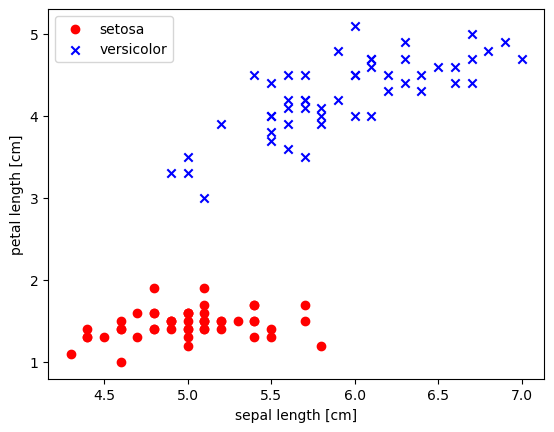


Before updates: Value of xi = [5.1 1.4] and y = -1. The perceptrons values are [-0.00611756 -0.00528172] and 0.01624345363663242
The value for net input is -0.022350527991209804 and for predict -1

After updates: Value of xi = [5.1 1.4] and y = -1. The perceptrons values are [-0.00611756 -0.00528172] and 0.01624345363663242
The parameters are 0.1. The values for the updates are [-0.00611756 -0.00528172] and 0.01624345363663242 and the number of errors are 0

Before updates: Value of xi = [4.9 1.4] and y = -1. The perceptrons values are [-0.00611756 -0.00528172] and 0.01624345363663242
The value for net input is -0.021127015163909656 and for predict -1

After updates: Value of xi = [4.9 1.4] and y = -1. The perceptrons values are [-0.00611756 -0.00528172] and 0.01624345363663242
The parameters are 0.1. The values for the updates are [-0.00611756 -0.00528172] and 0.01624345363663242 and the number of errors are 0

Before updates: Value of xi = [4.7 1.3] and y = -1. The perceptrons value

In [116]:
'''Visual representation'''
import matplotlib.pyplot as plt
import numpy as np

# Selects setosa and versicolor
y = df.iloc[0:100, 4].values

# Sets the features as -1 and 1. 1 to versicolor and -1 otherwise (setosa)
y = np.where(y == 'Iris-setosa', -1, 1)

# extract sepal length and petal length
X = df.iloc[0:100, [0, 2]].values

# Plotting the data
plt.scatter(X[:50, 0], X[:50, 1],
            color='red', marker='o', label='setosa')
plt.scatter(X[50:100, 0], X[50:100, 1],
            color='blue', marker='x', label='versicolor') 

plt.xlabel('sepal length [cm]')
plt.ylabel('petal length [cm]')
plt.legend(loc='upper left')
plt.show()
ppn = Perceptron(eta=0.1, n_iter=10)
ppn.fit(X, y)

### A linear classifier such as the perceptron should be able to classify the flowers in this dataset perfectly.


Before updates: Value of xi = [5.1 1.4] and y = -1. The perceptrons values are [-0.00611756 -0.00528172] and 0.01624345363663242
The value for net input is -0.022350527991209804 and for predict -1

After updates: Value of xi = [5.1 1.4] and y = -1. The perceptrons values are [-0.00611756 -0.00528172] and 0.01624345363663242
The parameters are 0.1. The values for the updates are [-0.00611756 -0.00528172] and 0.01624345363663242 and the number of errors are 0

Before updates: Value of xi = [4.9 1.4] and y = -1. The perceptrons values are [-0.00611756 -0.00528172] and 0.01624345363663242
The value for net input is -0.021127015163909656 and for predict -1

After updates: Value of xi = [4.9 1.4] and y = -1. The perceptrons values are [-0.00611756 -0.00528172] and 0.01624345363663242
The parameters are 0.1. The values for the updates are [-0.00611756 -0.00528172] and 0.01624345363663242 and the number of errors are 0

Before updates: Value of xi = [4.7 1.3] and y = -1. The perceptrons value

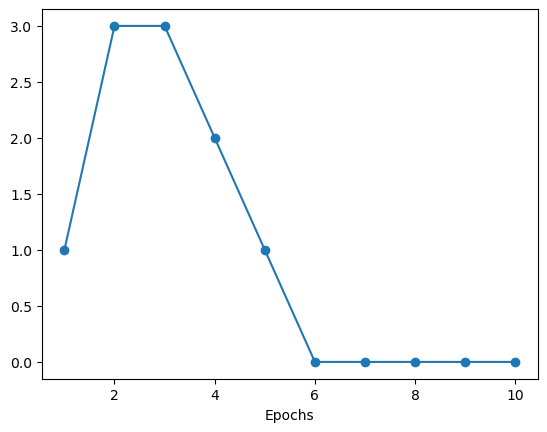

In [132]:
ppn = Perceptron(eta=0.1, n_iter=10)
ppn.fit(X, y)
print(len(ppn.errors_))
print(ppn.errors_)
plt.plot(range(1, len(ppn.errors_) + 1), 
         ppn.errors_, marker='o')
plt.xlabel('Epochs')
plt.show()  

In [142]:
from matplotlib.colors import ListedColormap

def plot_decision_regions(X, y, classifier, resolution=0.02):

    # setup marker generator and color map
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('green', 'red', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # plot class samples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0],
                    y=X[y == cl, 1],
                    alpha=0.8,
                    c=colors[idx],
                    marker=markers[idx],
                    label=cl,
                    edgecolor='black')

C:\Users\seb91\AppData\Local\Temp\ipykernel_19460\4478432.py:23: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


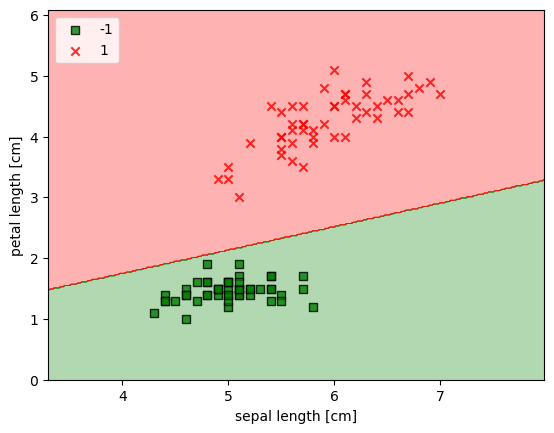

In [144]:
plot_decision_regions(X, y, classifier=ppn)
plt.xlabel('sepal length [cm]')
plt.ylabel('petal length [cm]')
plt.legend(loc='upper left')
plt.show()

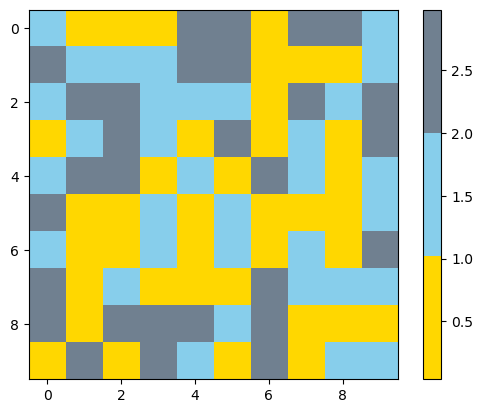

In [146]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import numpy as np

# Define your custom colors
my_colors = ["#FFD700", "#87CEEB", "#708090"]
my_cmap = ListedColormap(my_colors)

# Use it in a plot
data = np.random.rand(10, 10) * 3
plt.imshow(data, cmap=my_cmap)
plt.colorbar()
plt.show()